### 추가 데이터 전처리

### 동 인구수

In [1]:
import pandas as pd

# 1. 데이터 로드
population_path = r"C:\Users\yutt4\Downloads\동인구수21.csv"
population = pd.read_csv(population_path, encoding="cp949")

# 2. STATION_NO를 문자열로 변환
population["STATION_NO"] = population["STATION_NO"].astype(str)

# 3. 필요 없는 열 제거
population = population.drop(columns=["역이름", "동"], errors="ignore")

# 4. 데이터 세로형 변환 (melt)
population = population.melt(
    id_vars=["구", "STATION_NO"],  # 고정 열
    var_name="YEAR_MONTH",  # 열 이름이었던 연월 데이터
    value_name="DONG_POPULATION"  # 값이었던 동 인구 데이터
)

# 5. YEAR_MONTH 열 데이터 검증 및 변환
# 숫자가 아닌 데이터 제거
population = population[population["YEAR_MONTH"].str.match(r"^\d{4}\.\d{2}$")]

# 날짜 형식으로 변환
population["YEAR_MONTH"] = pd.to_datetime(population["YEAR_MONTH"], format="%Y.%m", errors="coerce")

# 6. 쉼표 제거 및 숫자 변환
population["DONG_POPULATION"] = (
    population["DONG_POPULATION"]
    .replace(",", "", regex=True)  # 쉼표 제거
    .apply(pd.to_numeric, errors="coerce")  # 숫자로 변환
)

# 7. 년(YEAR) 및 월(MONTH) 추가
population["YEAR"] = population["YEAR_MONTH"].dt.year
population["MONTH"] = population["YEAR_MONTH"].dt.month

# 8. STATION_NO와 YEAR_MONTH 기준으로 그룹화 및 합산
population = population.groupby(["STATION_NO", "YEAR", "MONTH", "YEAR_MONTH"], as_index=False)["DONG_POPULATION"].sum()

# 결과 확인
population.head(60)

,STATION_NO,YEAR,MONTH,YEAR_MONTH,DONG_POPULATION
0,1101,2021,1,2021-01-01,21179.0
1,1101,2021,2,2021-02-01,21092.0
2,1101,2021,3,2021-03-01,21027.0
3,1101,2021,4,2021-04-01,21011.0
4,1101,2021,5,2021-05-01,21040.0
5,1101,2021,6,2021-06-01,21030.0
6,1101,2021,7,2021-07-01,21024.0
7,1101,2021,8,2021-08-01,21003.0
8,1101,2021,9,2021-09-01,20971.0
9,1101,2021,11,2021-11-01,20927.0


In [5]:
import pandas as pd

# 'utf-8' 인코딩 시도.
data = pd.read_csv(r"C:\Users\yutt4\OneDrive\문서\data_base.csv", encoding='utf-8')

data.head(60)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,87,85,93,77,41,46,28,21,17,3
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,102,98,107,77,97,72,87,70,32,11
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,31,34,34,28,13,19,21,9,2,0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,25,37,32,31,34,29,38,22,19,2
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,107,97,80,71,44,57,40,27,19,0
5,2021-01-01,1103,하차,0,0,0,0,7,23,23,...,67,84,69,88,78,54,90,49,59,3
6,2021-01-01,1104,승차,0,0,0,0,10,27,56,...,315,276,285,229,170,154,182,113,41,0
7,2021-01-01,1104,하차,0,0,0,0,35,63,73,...,220,231,198,166,120,120,105,36,12,1
8,2021-01-01,1105,승차,0,0,0,0,9,12,28,...,169,211,236,208,195,210,278,94,34,2
9,2021-01-01,1105,하차,0,0,0,0,6,18,47,...,225,247,223,164,115,62,76,37,26,4


In [6]:
population.head(60)

,STATION_NO,YEAR,MONTH,YEAR_MONTH,DONG_POPULATION
0,1101,2021,1,2021-01-01,21179.0
1,1101,2021,2,2021-02-01,21092.0
2,1101,2021,3,2021-03-01,21027.0
3,1101,2021,4,2021-04-01,21011.0
4,1101,2021,5,2021-05-01,21040.0
5,1101,2021,6,2021-06-01,21030.0
6,1101,2021,7,2021-07-01,21024.0
7,1101,2021,8,2021-08-01,21003.0
8,1101,2021,9,2021-09-01,20971.0
9,1101,2021,11,2021-11-01,20927.0


In [7]:
# 예시 데이터 로딩
# data = pd.read_csv("data.csv")  # 실제 data 파일 경로
# population = pd.read_csv("population.csv")  # 실제 population 파일 경로

# 'BUSINESS_DAY'를 날짜 형식으로 변환
data['BUSINESS_DAY'] = pd.to_datetime(data['BUSINESS_DAY'])

# 'BUSINESS_DAY'에서 월을 추출하여 'MONTH' 열 생성
data['MONTH'] = data['BUSINESS_DAY'].dt.month

# 'STATION_NO'의 데이터 유형을 int로 변환
data['STATION_NO'] = data['STATION_NO'].astype(int)
population['STATION_NO'] = population['STATION_NO'].astype(int)

# population에서 중복된 STATION_NO와 MONTH의 DONG_POPULATION만 남기기
population_unique = population.drop_duplicates(subset=['STATION_NO', 'MONTH'])

# 'data'와 'population_unique'를 'STATION_NO'와 'MONTH'를 기준으로 병합
merged_data = pd.merge(data, population_unique[['STATION_NO', 'MONTH', 'DONG_POPULATION']], 
                       on=['STATION_NO', 'MONTH'],
                       how='left')

# 결과 확인
merged_data.head(60)
#베이스 데이터에 동인구수가 추가된 결과가 나옴

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,MONTH,DONG_POPULATION
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,93,77,41,46,28,21,17,3,1,21179.0
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,107,77,97,72,87,70,32,11,1,21179.0
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,28,13,19,21,9,2,0,1,37367.0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,32,31,34,29,38,22,19,2,1,37367.0
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,80,71,44,57,40,27,19,0,1,15059.0
5,2021-01-01,1103,하차,0,0,0,0,7,23,23,...,69,88,78,54,90,49,59,3,1,15059.0
6,2021-01-01,1104,승차,0,0,0,0,10,27,56,...,285,229,170,154,182,113,41,0,1,4950.0
7,2021-01-01,1104,하차,0,0,0,0,35,63,73,...,198,166,120,120,105,36,12,1,1,4950.0
8,2021-01-01,1105,승차,0,0,0,0,9,12,28,...,236,208,195,210,278,94,34,2,1,16107.0
9,2021-01-01,1105,하차,0,0,0,0,6,18,47,...,223,164,115,62,76,37,26,4,1,16107.0


In [11]:
import pandas as pd

# 예시 데이터 로딩
# data = pd.read_csv("data.csv")  # 실제 data 파일 경로
# population = pd.read_csv("population.csv")  # 실제 population 파일 경로

# 'BUSINESS_DAY'를 날짜 형식으로 변환
data['BUSINESS_DAY'] = pd.to_datetime(data['BUSINESS_DAY'])

# 'BUSINESS_DAY'에서 월을 추출하여 'MONTH' 열 생성
data['MONTH'] = data['BUSINESS_DAY'].dt.month

# 'STATION_NO'의 데이터 유형을 int로 변환
data['STATION_NO'] = data['STATION_NO'].astype(int)
population['STATION_NO'] = population['STATION_NO'].astype(int)

# population에서 중복된 STATION_NO와 MONTH의 DONG_POPULATION만 남기기
population_unique = population.drop_duplicates(subset=['STATION_NO', 'MONTH'])

# 'data'와 'population_unique'를 'STATION_NO'와 'MONTH'를 기준으로 병합
merged_data = pd.merge(data, population_unique[['STATION_NO', 'MONTH', 'DONG_POPULATION']], 
                       on=['STATION_NO', 'MONTH'],
                       how='left')

# 결과 확인
merged_data.head(60)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,MONTH,DONG_POPULATION
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,93,77,41,46,28,21,17,3,1,21179.0
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,107,77,97,72,87,70,32,11,1,21179.0
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,28,13,19,21,9,2,0,1,37367.0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,32,31,34,29,38,22,19,2,1,37367.0
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,80,71,44,57,40,27,19,0,1,15059.0
5,2021-01-01,1103,하차,0,0,0,0,7,23,23,...,69,88,78,54,90,49,59,3,1,15059.0
6,2021-01-01,1104,승차,0,0,0,0,10,27,56,...,285,229,170,154,182,113,41,0,1,4950.0
7,2021-01-01,1104,하차,0,0,0,0,35,63,73,...,198,166,120,120,105,36,12,1,1,4950.0
8,2021-01-01,1105,승차,0,0,0,0,9,12,28,...,236,208,195,210,278,94,34,2,1,16107.0
9,2021-01-01,1105,하차,0,0,0,0,6,18,47,...,223,164,115,62,76,37,26,4,1,16107.0


### 역 출입구 개수 코드

In [1]:

import pandas as pd

# 엑셀 파일 경로
exit_path = r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\출구 데이터.xlsx"

# 엑셀 파일 로드
exit = pd.read_excel(exit_path, engine='openpyxl')

# 데이터 확인
exit.head(60)


,역번호,역사,출입구 개수
0,1101,판암,4
1,1102,신흥,4
2,1103,대동,8
3,1104,대전,4
4,1105,중앙로,9
5,1106,중구청,4
6,1107,서대전네거리,8
7,1108,오룡,8
8,1109,용문,8
9,1110,탄방,5


In [2]:

import pandas as pd

# 엑셀 파일 경로
data_path = r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\merged_data.xlsx"

# 엑셀 파일 로드
data = pd.read_excel(data_path, engine='openpyxl')

# 데이터 확인
data.head(60)


,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,MONTH,DONG_POPULATION
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,93,77,41,46,28,21,17,3,1,21179.0
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,107,77,97,72,87,70,32,11,1,21179.0
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,28,13,19,21,9,2,0,1,37367.0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,32,31,34,29,38,22,19,2,1,37367.0
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,80,71,44,57,40,27,19,0,1,15059.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60231,2024-09-30,1120,하차,0,0,0,0,19,40,198,...,404,576,321,191,237,168,96,27,9,22038.0
60232,2024-09-30,1121,승차,0,0,0,0,40,79,170,...,216,481,152,113,82,40,25,0,9,24693.0
60233,2024-09-30,1121,하차,0,0,0,0,20,39,132,...,162,209,114,92,85,87,59,11,9,24693.0
60234,2024-09-30,1122,승차,0,0,0,0,72,204,903,...,527,833,394,261,253,239,114,0,9,37631.0


In [3]:
data.head(60)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,MONTH,DONG_POPULATION
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,93,77,41,46,28,21,17,3,1,21179.0
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,107,77,97,72,87,70,32,11,1,21179.0
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,28,13,19,21,9,2,0,1,37367.0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,32,31,34,29,38,22,19,2,1,37367.0
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,80,71,44,57,40,27,19,0,1,15059.0
5,2021-01-01,1103,하차,0,0,0,0,7,23,23,...,69,88,78,54,90,49,59,3,1,15059.0
6,2021-01-01,1104,승차,0,0,0,0,10,27,56,...,285,229,170,154,182,113,41,0,1,4950.0
7,2021-01-01,1104,하차,0,0,0,0,35,63,73,...,198,166,120,120,105,36,12,1,1,4950.0
8,2021-01-01,1105,승차,0,0,0,0,9,12,28,...,236,208,195,210,278,94,34,2,1,16107.0
9,2021-01-01,1105,하차,0,0,0,0,6,18,47,...,223,164,115,62,76,37,26,4,1,16107.0


In [4]:
# 원본 데이터 다시 로드
exit = pd.DataFrame({
    "역번호": [1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1120, 1121, 1122],
    "역사": ["판암", "신흥", "대동", "대전", "중앙로", "중구청", "서대전네거리", "오룡", "용문", "탄방", "시청", "정부청사", "갈마", "월평", "갑천", "유성온천", "구암", "현충원", "월드컵경기장", "노은", "지족", "반석"],
    "출입구 개수": [4, 4, 8, 4, 9, 4, 8, 8, 8, 5, 8, 4, 4, 4, 3, 8, 3, 4, 7, 4, 2, 6]
})

# 열 이름 변경
exit.rename(columns={"역번호": "STATION_NO"}, inplace=True)


In [5]:
exit.head(60)

,STATION_NO,역사,출입구 개수
0,1101,판암,4
1,1102,신흥,4
2,1103,대동,8
3,1104,대전,4
4,1105,중앙로,9
5,1106,중구청,4
6,1107,서대전네거리,8
7,1108,오룡,8
8,1109,용문,8
9,1110,탄방,5


In [6]:
import pandas as pd


# 'exit'에서 'STATION_NO'와 '출입구 개수' 컬럼만 선택
exit_selected = exit[['STATION_NO', '출입구 개수']]

# 'data'와 'exit_selected'를 'STATION_NO' 기준으로 left join
data = pd.merge(data, exit_selected, on='STATION_NO', how='left')

# 결과 확인
data.head(60)


,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,MONTH,DONG_POPULATION,출입구 개수
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,77,41,46,28,21,17,3,1,21179.0,4
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,77,97,72,87,70,32,11,1,21179.0,4
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,28,13,19,21,9,2,0,1,37367.0,4
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,31,34,29,38,22,19,2,1,37367.0,4
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,71,44,57,40,27,19,0,1,15059.0,8
5,2021-01-01,1103,하차,0,0,0,0,7,23,23,...,88,78,54,90,49,59,3,1,15059.0,8
6,2021-01-01,1104,승차,0,0,0,0,10,27,56,...,229,170,154,182,113,41,0,1,4950.0,4
7,2021-01-01,1104,하차,0,0,0,0,35,63,73,...,166,120,120,105,36,12,1,1,4950.0,4
8,2021-01-01,1105,승차,0,0,0,0,9,12,28,...,208,195,210,278,94,34,2,1,16107.0,9
9,2021-01-01,1105,하차,0,0,0,0,6,18,47,...,164,115,62,76,37,26,4,1,16107.0,9


In [7]:
# 'exit' 데이터프레임에서 'STATION_NO'와 '출입구 개수' 컬럼만 남겨두기
exit_columns = exit[['STATION_NO', '출입구 개수']]

# 'data'와 'exit_columns' 병합
data = pd.merge(data, exit_columns, on='STATION_NO', how='left')

# '출입구 개수_x'와 '출입구 개수_y' 컬럼이 있다면 제거
if '출입구 개수_x' in data.columns and '출입구 개수_y' in data.columns:
    data = data.drop(columns=['출입구 개수_x', '출입구 개수_y'])

# 결과 확인
data.head() 


,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,MONTH,DONG_POPULATION
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,93,77,41,46,28,21,17,3,1,21179.0
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,107,77,97,72,87,70,32,11,1,21179.0
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,28,13,19,21,9,2,0,1,37367.0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,32,31,34,29,38,22,19,2,1,37367.0
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,80,71,44,57,40,27,19,0,1,15059.0


In [8]:
# 'exit' 데이터프레임에서 'STATION_NO'와 '출입구 개수' 컬럼만 남겨두고, '출입구 개수' 이름을 변경
exit_columns = exit[['STATION_NO', '출입구 개수']].rename(columns={'출입구 개수': 'exit_출입구 개수'})

# 'data'와 'exit_columns' 병합
data = pd.merge(data, exit_columns, on='STATION_NO', how='left')

# 병합 후 'exit_출입구 개수'를 '출입구 개수'로 다시 이름 변경
data = data.rename(columns={'exit_출입구 개수': '출입구 개수'})

# 결과 확인
data.head(60)
#결과 사전에 결합한 데이터(베이스 데이터에 동인구수 열을 결합한)에 출입구 개수열을 추가한 결과 출력.

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,MONTH,DONG_POPULATION,출입구 개수
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,77,41,46,28,21,17,3,1,21179.0,4
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,77,97,72,87,70,32,11,1,21179.0,4
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,28,13,19,21,9,2,0,1,37367.0,4
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,31,34,29,38,22,19,2,1,37367.0,4
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,71,44,57,40,27,19,0,1,15059.0,8
5,2021-01-01,1103,하차,0,0,0,0,7,23,23,...,88,78,54,90,49,59,3,1,15059.0,8
6,2021-01-01,1104,승차,0,0,0,0,10,27,56,...,229,170,154,182,113,41,0,1,4950.0,4
7,2021-01-01,1104,하차,0,0,0,0,35,63,73,...,166,120,120,105,36,12,1,1,4950.0,4
8,2021-01-01,1105,승차,0,0,0,0,9,12,28,...,208,195,210,278,94,34,2,1,16107.0,9
9,2021-01-01,1105,하차,0,0,0,0,6,18,47,...,164,115,62,76,37,26,4,1,16107.0,9


In [10]:
# 해당 결과를 엑셀 파일로 저장
file_path = r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\역 출구 결합.xlsx"

# 'data'를 엑셀로 저장
data.to_excel(file_path, index=False)

file_path


'C:\\Users\\LG\\OneDrive\\Desktop\\동인구 전처리\\2023.11.3주차\\역 출구 결합.xlsx'

In [14]:
a = pd.read_csv(r"c:\Users\LG\OneDrive\문서\카카오톡 받은 파일\2021.csv",encoding = "utf8")
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5961 entries, 0 to 5960
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   BUSSTATION_NO  5961 non-null   int64 
 1   BUSINESS_DAY   5961 non-null   object
 2   1              5961 non-null   int64 
 3   2              5961 non-null   int64 
 4   3              5961 non-null   int64 
 5   4              5961 non-null   int64 
 6   5              5961 non-null   int64 
 7   6              5961 non-null   int64 
 8   7              5961 non-null   int64 
 9   8              5961 non-null   int64 
 10  9              5961 non-null   int64 
 11  10             5961 non-null   int64 
 12  11             5961 non-null   int64 
 13  12             5961 non-null   int64 
 14  13             5961 non-null   int64 
 15  14             5961 non-null   int64 
 16  15             5961 non-null   int64 
 17  16             5961 non-null   int64 
 18  17             5961 non-null

In [15]:
# BUSINESS_DAY 열을 datetime 형식으로 변환
a['BUSINESS_DAY'] = pd.to_datetime(a['BUSINESS_DAY'])

# BUSINESS_DAY를 YYYYMMDD 형식의 문자열로 변환
a['BUSINESS_DAY'] = a['BUSINESS_DAY'].dt.strftime('%Y%m%d')
a

,BUSSTATION_NO,BUSINESS_DAY,1,2,3,4,5,6,7,8,...,15,16,17,18,19,20,21,22,23,0
0,1104,20210102,0,0,0,0,0,24,28,45,...,125,100,88,73,41,53,41,34,5,0
1,1104,20210102,0,0,0,0,5,22,53,64,...,148,158,141,110,62,35,39,24,0,0
2,1104,20210102,0,0,0,0,9,60,87,129,...,248,265,217,165,80,42,38,25,3,0
3,1104,20210102,0,0,0,0,2,6,8,23,...,35,66,38,39,21,24,7,6,0,0
4,1104,20210102,0,0,0,0,1,3,16,26,...,39,30,39,15,8,6,9,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5956,1119,20211226,0,0,0,0,0,0,0,0,...,1,2,0,2,0,0,0,0,0,0
5957,1117,20211226,0,0,0,0,0,0,0,0,...,0,2,3,0,1,0,2,0,0,0
5958,1116,20211226,0,0,0,0,0,1,3,1,...,0,1,2,2,4,1,0,0,0,0
5959,1117,20211226,0,0,0,0,0,0,0,0,...,2,7,7,5,5,6,3,5,0,0


In [16]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5961 entries, 0 to 5960
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   BUSSTATION_NO  5961 non-null   int64 
 1   BUSINESS_DAY   5961 non-null   object
 2   1              5961 non-null   int64 
 3   2              5961 non-null   int64 
 4   3              5961 non-null   int64 
 5   4              5961 non-null   int64 
 6   5              5961 non-null   int64 
 7   6              5961 non-null   int64 
 8   7              5961 non-null   int64 
 9   8              5961 non-null   int64 
 10  9              5961 non-null   int64 
 11  10             5961 non-null   int64 
 12  11             5961 non-null   int64 
 13  12             5961 non-null   int64 
 14  13             5961 non-null   int64 
 15  14             5961 non-null   int64 
 16  15             5961 non-null   int64 
 17  16             5961 non-null   int64 
 18  17             5961 non-null

### 강수량(mm),일 최심신적설,눈_일수 코드

In [5]:
import pandas as pd

# 1. 데이터 로드
data = r"C:\Users\yutt4\Downloads\역 출구 결합.xlsx"
data_1 = pd.read_excel(data, engine='openpyxl')

data_1.head(6)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,MONTH,DONG_POPULATION,출입구 개수
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,77,41,46,28,21,17,3,1,21179.0,4
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,77,97,72,87,70,32,11,1,21179.0,4
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,28,13,19,21,9,2,0,1,37367.0,4
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,31,34,29,38,22,19,2,1,37367.0,4
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,71,44,57,40,27,19,0,1,15059.0,8
5,2021-01-01,1103,하차,0,0,0,0,7,23,23,...,88,78,54,90,49,59,3,1,15059.0,8


In [ ]:
# 데이터 로드
rain_data = r"C:\Users\yutt4\OneDrive\문서\extremum_20241129161636.csv"
data_2 = pd.read_csv(rain_data, encoding='utf-8')

# 비가 안 온날은 0으로 처리
data_2.head(6)

,BUSINESS_DAY,강수량(mm)
0,2021-01-01,2.1
1,2021-01-02,0.0
2,2021-01-03,NaN
3,2021-01-04,NaN
4,2021-01-05,0.1
5,2021-01-06,2.2


In [ ]:
# 데이터 로드
snow_data = r"C:\Users\yutt4\OneDrive\문서\STCS_눈일수_MNH_20241129162044.csv"
data_2 = pd.read_csv(snow_data, encoding='utf-8')

# 눈이 온 날만 기록되어 있어 안 온날은 날짜를 만들어 0으로 처리하고 눈이 안 쌓인 날은 일 최심신적설이
# 포함되어 있지않아 눈_일수 열을 만들어 따로 눈 온날은 1, 오지 않은 날은 0으로 처리
data_2.head(6)

,BUSINESS_DAY,지점,기상현상,일 최심신적설(cm)
0,2021-01-01,대전,눈,4.3
1,2021-01-02,대전,눈,-
2,2021-01-05,대전,눈,0.1
3,2021-01-06,대전,눈,5.8
4,2021-01-07,대전,눈,3
5,2021-01-12,대전,눈,2.1


In [10]:
import pandas as pd

# 파일 경로 설정
data_base_path = r"C:\Users\yutt4\Downloads\역 출구 결합.csv"
rain_data_path = r"C:\Users\yutt4\OneDrive\문서\extremum_20241129161636.csv"
snow_data_path = r"C:\Users\yutt4\OneDrive\문서\STCS_눈일수_MNH_20241129162044.csv"
output_path = r"C:\Users\yutt4\Downloads\data_base_snow_rain.csv"

# CSV 파일 읽기
data_base = pd.read_csv(data_base_path)
rain_data = pd.read_csv(rain_data_path)
snow_data = pd.read_csv(snow_data_path)

# 데이터 병합
# 여기서는 'key_column'을 공통 키로 사용한다고 가정합니다. 실제 키로 변경해야 합니다.
merged_data = pd.merge(data_base, rain_data, on='BUSINESS_DAY', how='left')
merged_data = pd.merge(merged_data, snow_data, on='BUSINESS_DAY', how='left')

# 결과를 새로운 CSV 파일로 저장
merged_data.to_csv(output_path, index=False)

print(f"병합된 데이터가 {output_path}에 저장되었습니다.")


병합된 데이터가 C:\Users\yutt4\Downloads\data_base_snow_rain.csv에 저장되었습니다.


In [14]:
# 데이터 로드
w_data = r"C:\Users\yutt4\Downloads\data_base_snow_rain.csv"
w_data_1 = pd.read_csv(w_data, encoding='utf-8')

# 데이터 합쳐서 불러오기
data_2.head(6)

,BUSINESS_DAY,지점,기상현상,일 최심신적설(cm)
0,2021-01-01,대전,눈,4.3
1,2021-01-02,대전,눈,-
2,2021-01-05,대전,눈,0.1
3,2021-01-06,대전,눈,5.8
4,2021-01-07,대전,눈,3
5,2021-01-12,대전,눈,2.1


### 대전행정구역, 유동인구 수 코드
- 유동인구는 주차별로 되어있어서 1주일이 7일이므로 7로 나누어서 값을 넣으려고함
- 1101~1122까지 동구,서구,중구,유성구로 나누고
- date.base 에 열을 추가하려고 함. 그리고 유동인구로 7로 나눈 값은 일자별로 해당하는 중구,서구,동구,유성구에 해당하는 값을 집어넣으려고 했음

In [1]:
# 데이터 불러오기

import pandas as pd

# 엑셀 파일 경로 설정
data_path = r"C:\Users\yutt4\Downloads\유동인구22.xlsx"

# 엑셀 파일 읽어오기
so = pd.read_excel(data_path, engine='openpyxl')
so

,주차구분,2021.01.1,2021.01.2,2021.01.3,2021.01.4,2021.02.1,2021.02.2,2021.02.3,2021.02.4,2021.03.1,...,2024.07.4,2024.08.1,2024.08.2,2024.08.3,2024.08.4,2024.08.5,2024.09.1,2024.09.2,2024.09.3,2024.09.4
0,동구,448565,467454,465151,460152,480157,475901,480522,490113,514884,...,529545,535508,543108,544936,540595,557288,572650,578375,555566,584545
1,서구,914639,948898,962412,963523,981701,927395,989387,998800,1002435,...,1115079,1100703,1109703,1090179,1112633,1132314,1151251,1150564,1052143,1147614
2,유성구,641484,664693,673787,673939,690855,630459,695571,708800,719880,...,829228,823084,821793,818592,819086,835827,862097,847800,767777,863366
3,중구,491123,511793,523945,517097,529371,516867,532756,542583,543454,...,598777,601212,619278,618184,593751,606260,610994,614946,583939,623578


In [2]:
so.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Columns: 196 entries, 주차구분 to 2024.09.4
dtypes: int64(195), object(1)
memory usage: 6.3+ KB


In [3]:
so.describe()

,2021.01.1,2021.01.2,2021.01.3,2021.01.4,2021.02.1,2021.02.2,2021.02.3,2021.02.4,2021.03.1,2021.03.2,...,2024.07.4,2024.08.1,2024.08.2,2024.08.3,2024.08.4,2024.08.5,2024.09.1,2024.09.2,2024.09.3,2024.09.4
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000e+00,4.000000e+00,...,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
mean,623952.750000,648209.500000,656323.750000,653677.750000,670521.000000,637655.500000,674559.000000,685074.000000,6.951632e+05,7.071622e+05,...,7.681572e+05,7.651268e+05,7.734705e+05,7.679728e+05,7.665162e+05,7.829222e+05,7.992480e+05,7.979212e+05,7.398562e+05,8.047758e+05
std,210721.337316,217537.193798,222160.704358,225478.095302,226132.880516,203924.125984,228995.357963,228983.553088,2.240113e+05,2.323344e+05,...,2.643923e+05,2.553189e+05,2.531334e+05,2.439681e+05,2.604155e+05,2.626746e+05,2.674835e+05,2.636445e+05,2.284554e+05,2.596826e+05
min,448565.000000,467454.000000,465151.000000,460152.000000,480157.000000,475901.000000,480522.000000,490113.000000,5.148840e+05,5.172660e+05,...,5.295450e+05,5.355080e+05,5.431080e+05,5.449360e+05,5.405950e+05,5.572880e+05,5.726500e+05,5.783750e+05,5.555660e+05,5.845450e+05
25%,480483.500000,500708.250000,509246.500000,502860.750000,517067.500000,506625.500000,519697.500000,529465.500000,5.363115e+05,5.425268e+05,...,5.814690e+05,5.847860e+05,6.002355e+05,5.998720e+05,5.804620e+05,5.940170e+05,6.014080e+05,6.058032e+05,5.768458e+05,6.138198e+05
50%,566303.500000,588243.000000,598866.000000,595518.000000,610113.000000,573663.000000,614163.500000,625691.500000,6.316670e+05,6.434910e+05,...,7.140025e+05,7.121480e+05,7.205355e+05,7.183880e+05,7.064185e+05,7.210435e+05,7.365455e+05,7.313730e+05,6.758580e+05,7.434720e+05
75%,709772.750000,735744.250000,745943.250000,746335.000000,763566.500000,704693.000000,769025.000000,781300.000000,7.905188e+05,8.081265e+05,...,9.006908e+05,8.924888e+05,8.937705e+05,8.864888e+05,8.924728e+05,9.099488e+05,9.343855e+05,9.234910e+05,8.388685e+05,9.344280e+05
max,914639.000000,948898.000000,962412.000000,963523.000000,981701.000000,927395.000000,989387.000000,998800.000000,1.002435e+06,1.024401e+06,...,1.115079e+06,1.100703e+06,1.109703e+06,1.090179e+06,1.112633e+06,1.132314e+06,1.151251e+06,1.150564e+06,1.052143e+06,1.147614e+06


In [4]:
so.head()

,주차구분,2021.01.1,2021.01.2,2021.01.3,2021.01.4,2021.02.1,2021.02.2,2021.02.3,2021.02.4,2021.03.1,...,2024.07.4,2024.08.1,2024.08.2,2024.08.3,2024.08.4,2024.08.5,2024.09.1,2024.09.2,2024.09.3,2024.09.4
0,동구,448565,467454,465151,460152,480157,475901,480522,490113,514884,...,529545,535508,543108,544936,540595,557288,572650,578375,555566,584545
1,서구,914639,948898,962412,963523,981701,927395,989387,998800,1002435,...,1115079,1100703,1109703,1090179,1112633,1132314,1151251,1150564,1052143,1147614
2,유성구,641484,664693,673787,673939,690855,630459,695571,708800,719880,...,829228,823084,821793,818592,819086,835827,862097,847800,767777,863366
3,중구,491123,511793,523945,517097,529371,516867,532756,542583,543454,...,598777,601212,619278,618184,593751,606260,610994,614946,583939,623578


In [8]:
# 결측값 여부 확인
so.isnull().sum()  # 각 컬럼에 있는 결측값의 개수를 확인

주차구분         0
2021.01.1    0
2021.01.2    0
2021.01.3    0
2021.01.4    0
            ..
2024.08.5    0
2024.09.1    0
2024.09.2    0
2024.09.3    0
2024.09.4    0
Length: 196, dtype: int64

In [9]:
# 데이터 불러오기

import pandas as pd

# 엑셀 파일 경로 설정
data_path = r"C:\Users\yutt4\OneDrive\문서\data_base.csv"

# 엑셀 파일 읽어오기
df = pd.read_csv(data_path)
df

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,87,85,93,77,41,46,28,21,17,3
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,102,98,107,77,97,72,87,70,32,11
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,31,34,34,28,13,19,21,9,2,0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,25,37,32,31,34,29,38,22,19,2
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,107,97,80,71,44,57,40,27,19,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60231,2024-09-30,1120,하차,0,0,0,0,19,40,198,...,303,349,404,576,321,191,237,168,96,27
60232,2024-09-30,1121,승차,0,0,0,0,40,79,170,...,127,143,216,481,152,113,82,40,25,0
60233,2024-09-30,1121,하차,0,0,0,0,20,39,132,...,136,128,162,209,114,92,85,87,59,11
60234,2024-09-30,1122,승차,0,0,0,0,72,204,903,...,349,400,527,833,394,261,253,239,114,0


In [11]:
station_to_region = {
    1107: '중구',
    1103: '동구', 1104: '동구', 1108: '중구', 1109: '서구',
    1116: '유성구', 1117: '유성구', 1118: '유성구', 1121: '유성구', 1122: '유성구',
    1110: '서구', 1111: '서구', 1112: '서구', 1113: '서구',
    1114: '서구', 1115: '서구', 1119: '유성구', 1120: '유성구',
    1101: '동구', 1102: '동구', 1105: '중구', 1106: '중구'
}

# STATION_NO 값에 따라 대전행정구역 열 추가
df['대전행정구역'] = df['STATION_NO'].map(station_to_region)
df

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,대전행정구역
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,동구
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,동구
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,동구
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,동구
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,동구
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60231,2024-09-30,1120,하차,0,0,0,0,19,40,198,...,349,404,576,321,191,237,168,96,27,유성구
60232,2024-09-30,1121,승차,0,0,0,0,40,79,170,...,143,216,481,152,113,82,40,25,0,유성구
60233,2024-09-30,1121,하차,0,0,0,0,20,39,132,...,128,162,209,114,92,85,87,59,11,유성구
60234,2024-09-30,1122,승차,0,0,0,0,72,204,903,...,400,527,833,394,261,253,239,114,0,유성구


In [12]:
# so 데이터프레임을 복사
so_copy = so.copy()

In [13]:
# 열 이름 출력
so_copy.columns

Index(['주차구분', '2021.01.1', '2021.01.2', '2021.01.3', '2021.01.4', '2021.02.1',
       '2021.02.2', '2021.02.3', '2021.02.4', '2021.03.1',
       ...
       '2024.07.4', '2024.08.1', '2024.08.2', '2024.08.3', '2024.08.4',
       '2024.08.5', '2024.09.1', '2024.09.2', '2024.09.3', '2024.09.4'],
      dtype='object', length=196)

In [15]:
# BUSINESS_DAY 열에서 중복된 값을 제외한 고유한 값들 확인
unique_business_days = df['BUSINESS_DAY'].drop_duplicates()
unique_business_days

0        2021-01-01
44       2021-01-02
88       2021-01-03
132      2021-01-04
176      2021-01-05
            ...    
60016    2024-09-26
60060    2024-09-27
60104    2024-09-28
60148    2024-09-29
60192    2024-09-30
Name: BUSINESS_DAY, Length: 1369, dtype: object

In [16]:
df

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,대전행정구역
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,동구
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,동구
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,동구
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,동구
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,동구
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60231,2024-09-30,1120,하차,0,0,0,0,19,40,198,...,349,404,576,321,191,237,168,96,27,유성구
60232,2024-09-30,1121,승차,0,0,0,0,40,79,170,...,143,216,481,152,113,82,40,25,0,유성구
60233,2024-09-30,1121,하차,0,0,0,0,20,39,132,...,128,162,209,114,92,85,87,59,11,유성구
60234,2024-09-30,1122,승차,0,0,0,0,72,204,903,...,400,527,833,394,261,253,239,114,0,유성구


In [17]:
# 숫자형 데이터에 대해서만 7로 나누기
so_numeric = so_copy.select_dtypes(include='number')  # 숫자형 데이터만 선택

# 모든 숫자형 데이터를 7로 나누기
so_copy[so_numeric.columns] = so_numeric / 7
so_copy

,주차구분,2021.01.1,2021.01.2,2021.01.3,2021.01.4,2021.02.1,2021.02.2,2021.02.3,2021.02.4,2021.03.1,...,2024.07.4,2024.08.1,2024.08.2,2024.08.3,2024.08.4,2024.08.5,2024.09.1,2024.09.2,2024.09.3,2024.09.4
0,동구,64080.714286,66779.142857,66450.142857,65736.000000,68593.857143,67985.857143,68646.000000,70016.142857,73554.857143,...,75649.285714,76501.142857,77586.857143,77848.000000,77227.857143,79612.571429,81807.142857,82625.000000,79366.571429,83506.428571
1,서구,130662.714286,135556.857143,137487.428571,137646.142857,140243.000000,132485.000000,141341.000000,142685.714286,143205.000000,...,159297.000000,157243.285714,158529.000000,155739.857143,158947.571429,161759.142857,164464.428571,164366.285714,150306.142857,163944.857143
2,유성구,91640.571429,94956.142857,96255.285714,96277.000000,98693.571429,90065.571429,99367.285714,101257.142857,102840.000000,...,118461.142857,117583.428571,117399.000000,116941.714286,117012.285714,119403.857143,123156.714286,121114.285714,109682.428571,123338.000000
3,중구,70160.428571,73113.285714,74849.285714,73871.000000,75624.428571,73838.142857,76108.000000,77511.857143,77636.285714,...,85539.571429,85887.428571,88468.285714,88312.000000,84821.571429,86608.571429,87284.857143,87849.428571,83419.857143,89082.571429


In [18]:
so_copy.iloc[0, 1] #동구
so_copy.iloc[1, 1] #서구
so_copy.iloc[2, 1] #유성구
so_copy.iloc[3, 1] #중구

70160.42857142857

In [4]:
import pandas as pd
##### 유동인구 값을 넣는 함수는 r로 진행해서 파일 불러오기
# 데이터 로드
pop_data = r"C:\Users\yutt4\Downloads\2021~2024.09.30 유동인구.csv"
pop_data_1 = pd.read_csv(pop_data, encoding='utf-8')

pop_data_1.head(30)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,대전행정구역,유동인구수
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,93,77,41,46,28,21,17,3,동구,64080.71429
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,107,77,97,72,87,70,32,11,동구,64080.71429
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,28,13,19,21,9,2,0,동구,64080.71429
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,32,31,34,29,38,22,19,2,동구,64080.71429
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,80,71,44,57,40,27,19,0,동구,64080.71429
5,2021-01-01,1103,하차,0,0,0,0,7,23,23,...,69,88,78,54,90,49,59,3,동구,64080.71429
6,2021-01-01,1104,승차,0,0,0,0,10,27,56,...,285,229,170,154,182,113,41,0,동구,64080.71429
7,2021-01-01,1104,하차,0,0,0,0,35,63,73,...,198,166,120,120,105,36,12,1,동구,64080.71429
8,2021-01-01,1105,승차,0,0,0,0,9,12,28,...,236,208,195,210,278,94,34,2,중구,70160.42857
9,2021-01-01,1105,하차,0,0,0,0,6,18,47,...,223,164,115,62,76,37,26,4,중구,70160.42857


### 역 주변 병원 수 코드

In [2]:
# pandas 라이브러리 불러오기
import pandas as pd

# 엑셀 파일 불러오기
hospital = pd.read_excel('역마다 주말에 운영하는 병원개수.xlsx')

# 상위 다섯개 행 확인
hospital.head(5)

,역이름,STATION_NO,hospital
0,판암,1101,6
1,신흥,1102,2
2,대동,1103,5
3,대전,1104,11
4,중앙로,1105,4


In [3]:
hospital.info()  # 데이터프레임의 기본 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   역이름         22 non-null     object
 1   STATION_NO  22 non-null     int64 
 2   hospital    22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [4]:
hospital.describe()  # 수치형 변수들의 통계적 요약 확인

,STATION_NO,hospital
count,22.000000,22.000000
mean,1111.500000,4.409091
std,6.493587,3.850282
min,1101.000000,0.000000
25%,1106.250000,1.250000
50%,1111.500000,4.000000
75%,1116.750000,6.000000
max,1122.000000,13.000000


In [5]:
hospital.isnull().sum()  # 각 열에 있는 결측값의 개수 확인

역이름           0
STATION_NO    0
hospital      0
dtype: int64

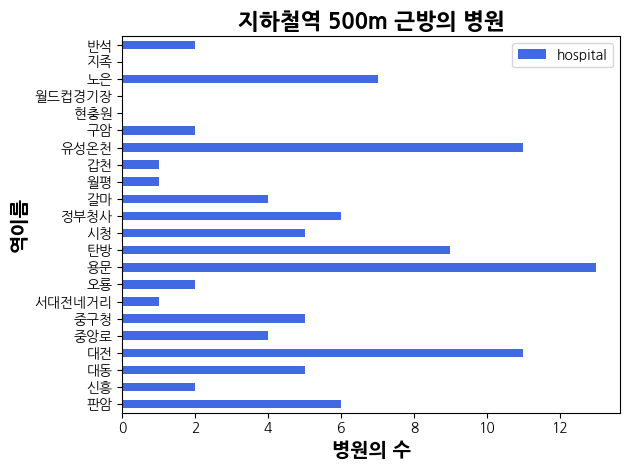

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'  # 또는 다른 한글 폰트 (예: 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 그래프 그리기(가로 막대그래프)
ax = hospital.plot.barh(x='역이름', y='hospital', color="royalblue")


# 그래프 제목 및 축 레이블 설정
ax.set_title("지하철역 500m 근방의 병원", fontsize=16, fontweight='bold')  # 제목 추가
ax.set_xlabel("병원의 수", fontsize=14, fontweight='bold')  # x축 제목
ax.set_ylabel("역이름", fontsize=14, fontweight='bold')  # y축 제목

# 그래프 표시
plt.tight_layout()  # 레이아웃 자동 조정
plt.show()

In [19]:
# CSV 파일 불러오기
data = pd.read_csv('data_base.csv')

# 상위 다섯개 행 확인
data.head(5)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,87,85,93,77,41,46,28,21,17,3
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,102,98,107,77,97,72,87,70,32,11
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,31,34,34,28,13,19,21,9,2,0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,25,37,32,31,34,29,38,22,19,2
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,107,97,80,71,44,57,40,27,19,0


In [20]:
# hospital_count 딕셔너리
hospital_count = {
1101	: 6,
1102	: 2,
1103	: 5,
1104	: 11,
1105	: 4,
1106	: 5,
1107	: 1,
1108	: 2,
1109	: 13,
1110	: 9,
1111	: 5,
1112	: 6,
1113	: 4,
1114	: 1,
1115	: 1,
1116	: 11,
1117	: 2,
1118	: 0,
1119	: 0,
1120	: 7,
1121	: 0,
1122	: 2}

# STATION_NO 값에 따라 hospital 열 추가
data['hospital'] = data['STATION_NO'].map(hospital_count)
data.head(5)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,hospital
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,6
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,6
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,2
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,2
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,5


In [18]:
# 엑셀 파일로 저장
data.to_excel('hospital_count.xlsx', index=False)

### 역 주변 숙박업소_수

In [2]:
# pandas 라이브러리 불러오기
import pandas as pd

# 1. 데이터 로드
data = r"C:\Users\yutt4\Downloads\역 주변 숙박업소 수.xlsx"
data_1 = pd.read_excel(data)

data_1.head(10)

,STATION_NO,숙박업소_수
0,1101,0
1,1102,0
2,1103,1
3,1104,13
4,1105,13
5,1106,6
6,1107,5
7,1108,1
8,1109,11
9,1110,0


In [3]:
data_1.info()  # 데이터프레임의 기본 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   STATION_NO  22 non-null     int64
 1   숙박업소_수      22 non-null     int64
dtypes: int64(2)
memory usage: 480.0 bytes


In [4]:
data_1.describe()  # 수치형 변수들의 통계적 요약 확인

,STATION_NO,숙박업소_수
count,22.000000,22.000000
mean,1111.500000,4.590909
std,6.493587,6.028970
min,1101.000000,0.000000
25%,1106.250000,0.000000
50%,1111.500000,0.500000
75%,1116.750000,10.250000
max,1122.000000,18.000000


In [5]:
data_1.isnull().sum()  # 각 열에 있는 결측값의 개수 확인

STATION_NO    0
숙박업소_수        0
dtype: int64

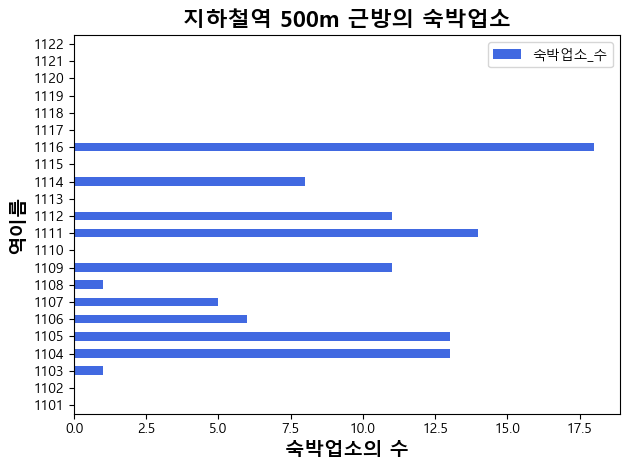

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 다른 한글 폰트 (예: 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 그래프 그리기(가로 막대그래프)
ax = data_1.plot.barh(x='STATION_NO', y='숙박업소_수', color="royalblue")


# 그래프 제목 및 축 레이블 설정
ax.set_title("지하철역 500m 근방의 숙박업소", fontsize=16, fontweight='bold')  # 제목 추가
ax.set_xlabel("숙박업소의 수", fontsize=14, fontweight='bold')  # x축 제목
ax.set_ylabel("역이름", fontsize=14, fontweight='bold')  # y축 제목

# 그래프 표시
plt.tight_layout()  # 레이아웃 자동 조정
plt.show()

In [7]:
import pandas as pd

# 파일 경로 설정
data_base_path = r"C:\Users\yutt4\OneDrive\문서\data_base.csv"  # 첫 번째 파일 경로
stations_path = r"C:\Users\yutt4\Downloads\역 주변 숙박업소 수.xlsx" # 두 번째 파일 경로
output_path = r"C:\Users\yutt4\Downloads\data_base_with_hotel_count.csv" # 병합 후 저장 경로

# 데이터 로드
data_base = pd.read_csv(data_base_path)
stations_data = pd.read_excel(stations_path)

# 병합
# 'STATION_NO'를 기준으로 병합. 키 이름은 파일에 따라 변경 필요
merged_data = pd.merge(data_base, stations_data, on='STATION_NO', how='left')

# 결과 저장
merged_data.to_csv(output_path, index=False)

print(f"병합된 파일이 {output_path}에 저장되었습니다.")

병합된 파일이 C:\Users\yutt4\Downloads\data_base_with_hotel_count.csv에 저장되었습니다.


In [8]:
# CSV 파일 불러오기
data_3 = pd.read_csv(r"C:\Users\yutt4\Downloads\data_base_with_hotel_count.csv")

# 상위 다섯개 행 확인
data_3.head(5)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,숙박업소_수
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,0
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,0
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,0
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,1


### 버스요금 추가 코드

In [21]:
# 파일 불러오기
data_4 = pd.read_excel(r"C:\Users\yutt4\Downloads\버스요금 데이터.xlsx")

# 상위 다섯개 행 확인
data_4.head(5)

,날짜,어린이 버스요금,청소년 버스요금,일반 버스요금
0,2021,350,750,1250
1,2022,350,750,1250
2,2023,350,750,1250
3,2024,350,750,1500


In [ ]:
##### 버스 요금은 데이터가 비교적 작아 엑셀에서 데이터 전처리 하여 데이터 추가

In [26]:
# 파일 불러오기
data_5 = pd.read_csv(r"C:\Users\yutt4\Downloads\Updated_BUS_all.csv",encoding='utf-8')

# 상위 다섯개 행 확인
data_5.head(5)

,BUSINESS_DAY,STATION_NO,BUS_CNT01,BUS_CNT02,BUS_CNT03,BUS_CNT04,BUS_CNT05,BUS_CNT06,BUS_CNT07,BUS_CNT08,...,BUS_CNT00,숙박업소,어린이 버스요금,청소년 버스요금,일반 버스요금,마트,약국,카페,교회_수,영화관
0,2021-01-01,1101,0,0,0,0,0,0,0,0,...,0,0,350.0,750.0,1250.0,9,9,23,2,0
1,2021-01-01,1101,0,0,0,0,0,0,0,0,...,0,0,350.0,750.0,1250.0,9,9,23,2,0
2,2021-01-01,1102,0,0,0,0,0,0,0,0,...,0,0,350.0,750.0,1250.0,5,4,5,1,0
3,2021-01-01,1102,0,0,0,0,0,0,0,0,...,0,0,350.0,750.0,1250.0,5,4,5,1,0
4,2021-01-01,1103,0,0,0,0,0,0,0,0,...,0,1,350.0,750.0,1250.0,10,6,31,4,0


### 마트 추가 코드

In [70]:
import pandas as pd  # pandas 라이브러리 불러오기

# 엑셀 파일 읽기
mart = pd.read_excel(r"C:\Users\woori\Desktop\ma\역500m의 마트.xlsx")  

# 상위 열개 행 확인
mart.head(10)

,역이름,STATION_NO,마트
0,판암,1101,9
1,신흥,1102,5
2,대동,1103,10
3,대전,1104,15
4,중앙로,1105,25
5,중구청,1106,8
6,서대전네거리,1107,8
7,오룡,1108,6
8,용문,1109,14
9,탄방,1110,9


In [8]:
mart.info()  # 데이터프레임의 기본 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   역이름         22 non-null     object
 1   STATION_NO  22 non-null     int64 
 2   마트          22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [9]:
mart.describe()  # 수치형 변수들의 통계적 요약 확인

,STATION_NO,마트
count,22.000000,22.000000
mean,1111.500000,8.272727
std,6.493587,5.044392
min,1101.000000,0.000000
25%,1106.250000,6.000000
50%,1111.500000,8.000000
75%,1116.750000,9.000000
max,1122.000000,25.000000


In [11]:
mart.isnull().sum()  # 각 열에 있는 결측값의 개수 확인

역이름           0
STATION_NO    0
마트            0
dtype: int64

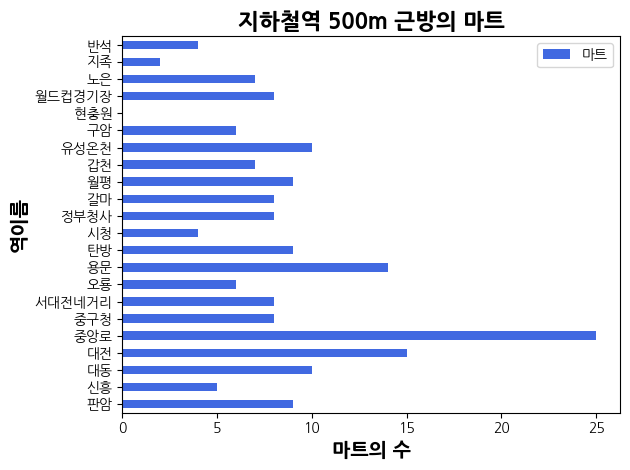

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 그래프 그리기(가로 막대그래프)
ax = mart.plot.barh(x='역이름', y='마트', color="royalblue")

# 그래프 제목 및 축 레이블 설정
ax.set_title("지하철역 500m 근방의 마트", fontsize=16, fontweight='bold')  # 제목 추가
ax.set_xlabel("마트의 수", fontsize=14, fontweight='bold')  # x축 제목
ax.set_ylabel("역이름", fontsize=14, fontweight='bold')  # y축 제목

# 그래프 표시
plt.tight_layout()  # 레이아웃 자동 조정
plt.show()


In [69]:
# CSV 파일 불러오기
data = pd.read_csv('data_base.csv')

# 상위 열개 행 확인
data.head(5)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,87,85,93,77,41,46,28,21,17,3
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,102,98,107,77,97,72,87,70,32,11
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,31,34,34,28,13,19,21,9,2,0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,25,37,32,31,34,29,38,22,19,2
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,107,97,80,71,44,57,40,27,19,0


In [ ]:
# mart_count 딕셔너리
mart_count = {
1101:9,1102:5,1103:10,1104:15,1105:25,1106:8,1107:8,1108:6,1109:14,1110:9,1111:4,1112:8,1113:8,1114:9,1115:7,1116:10,1117:6,1118:0,1119:8,1120:7,1121:2,1122:4
}

# 'STATION_NO' 값을 기준으로 각 역에 해당하는 마트의 수를 'Mart' 열에 추가
data['Mart'] = data['STATION_NO'].map(mart_count)
data

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,Mart
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,9
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,9
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,5
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,5
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60231,2024-09-30,1120,하차,0,0,0,0,19,40,198,...,349,404,576,321,191,237,168,96,27,7
60232,2024-09-30,1121,승차,0,0,0,0,40,79,170,...,143,216,481,152,113,82,40,25,0,2
60233,2024-09-30,1121,하차,0,0,0,0,20,39,132,...,128,162,209,114,92,85,87,59,11,2
60234,2024-09-30,1122,승차,0,0,0,0,72,204,903,...,400,527,833,394,261,253,239,114,0,4


In [6]:
# 엑셀 파일로 저장
data.to_excel('mart_count.xlsx', index=False)

### 카페 추가 코드

In [1]:
# pandas 라이브러리 불러오기
import pandas as pd

# 엑셀 파일 불러오기
cafe = pd.read_excel('역500m의 카페.xlsx')

# 상위 다섯개 행 확인
cafe.head(5)

,역이름,STATION_NO,cafe
0,판암,1101,23
1,신흥,1102,5
2,대동,1103,31
3,대전,1104,57
4,중앙로,1105,48


In [2]:
cafe.info()  # 데이터프레임의 기본 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   역이름         22 non-null     object
 1   STATION_NO  22 non-null     int64 
 2   cafe        22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [3]:
cafe.describe()  # 수치형 변수들의 통계적 요약 확인

,STATION_NO,cafe
count,22.000000,22.000000
mean,1111.500000,31.772727
std,6.493587,16.142024
min,1101.000000,2.000000
25%,1106.250000,23.500000
50%,1111.500000,31.000000
75%,1116.750000,42.750000
max,1122.000000,69.000000


In [4]:
cafe.isnull().sum()  # 각 열에 있는 결측값의 개수 확인

역이름           0
STATION_NO    0
cafe          0
dtype: int64

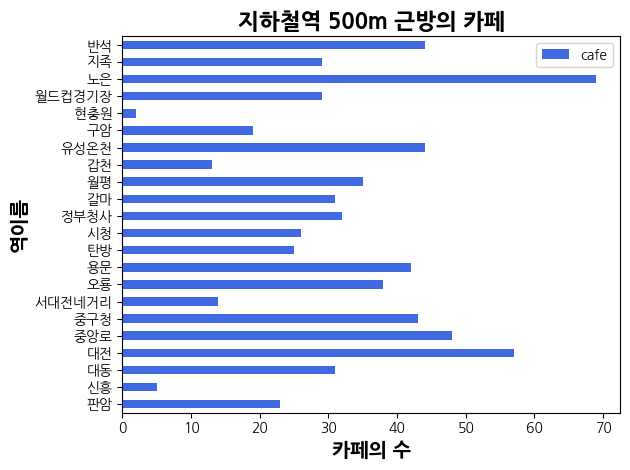

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'  # 또는 다른 한글 폰트 (예: 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 그래프 그리기(가로 막대그래프)
ax = cafe.plot.barh(x='역이름', y='cafe', color="royalblue")


# 그래프 제목 및 축 레이블 설정
ax.set_title("지하철역 500m 근방의 카페", fontsize=16, fontweight='bold')  # 제목 추가
ax.set_xlabel("카페의 수", fontsize=14, fontweight='bold')  # x축 제목
ax.set_ylabel("역이름", fontsize=14, fontweight='bold')  # y축 제목

# 그래프 표시
plt.tight_layout()  # 레이아웃 자동 조정
plt.show()

In [6]:
# CSV 파일 불러오기
data = pd.read_csv('data_base.csv')

# 상위 다섯개 행 확인
data.head(5)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,87,85,93,77,41,46,28,21,17,3
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,102,98,107,77,97,72,87,70,32,11
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,31,34,34,28,13,19,21,9,2,0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,25,37,32,31,34,29,38,22,19,2
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,107,97,80,71,44,57,40,27,19,0


In [7]:
# cafe_count 딕셔너리
cafe_count = {
1101:23,1102:5,1103:31,1104:57,1105:48,1106:43,1107:14,1108:38,1109:42,1110:25,1111:26,1112:32,1113:31,1114:35,1115:13,1116:44,1117:19,1118:2,1119:29,1120:69,1121:29,1122:44
}

# STATION_NO 값에 따라 cafe 열 추가
data['cafe'] = data['STATION_NO'].map(cafe_count)
data

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,cafe
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,23
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,23
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,5
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,5
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60231,2024-09-30,1120,하차,0,0,0,0,19,40,198,...,349,404,576,321,191,237,168,96,27,69
60232,2024-09-30,1121,승차,0,0,0,0,40,79,170,...,143,216,481,152,113,82,40,25,0,29
60233,2024-09-30,1121,하차,0,0,0,0,20,39,132,...,128,162,209,114,92,85,87,59,11,29
60234,2024-09-30,1122,승차,0,0,0,0,72,204,903,...,400,527,833,394,261,253,239,114,0,44


In [8]:
# 엑셀 파일로 저장
data.to_excel('cafe_count.xlsx', index=False)

### 교회 추가 코드

In [9]:
# pandas 라이브러리 불러오기
import pandas as pd

# 1. 데이터 로드
data_5= r"C:\Users\yutt4\Downloads\역 주변 교회_수.xlsx"
data_6 = pd.read_excel(data_5)

data_6.head(10)

,STATION_NO,교회_수
0,1101,2
1,1102,1
2,1103,4
3,1104,3
4,1105,2
5,1106,3
6,1107,1
7,1108,2
8,1109,2
9,1110,3


In [10]:
data_6.info()  # 데이터프레임의 기본 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   STATION_NO  22 non-null     int64
 1   교회_수        22 non-null     int64
dtypes: int64(2)
memory usage: 480.0 bytes


In [11]:
data_6.describe()  # 수치형 변수들의 통계적 요약 확인

,STATION_NO,교회_수
count,22.000000,22.000000
mean,1111.500000,1.454545
std,6.493587,1.223861
min,1101.000000,0.000000
25%,1106.250000,0.250000
50%,1111.500000,1.000000
75%,1116.750000,2.000000
max,1122.000000,4.000000


In [13]:
data_6.isnull().sum()  # 각 열에 있는 결측값의 개수 확인

STATION_NO    0
교회_수          0
dtype: int64

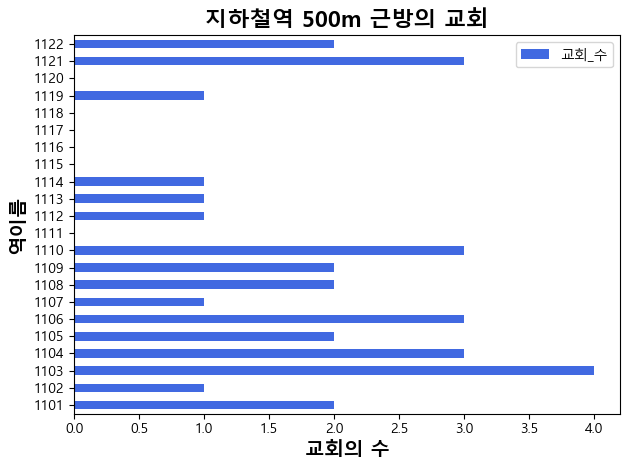

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 다른 한글 폰트 (예: 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 그래프 그리기(가로 막대그래프)
ax = data_6.plot.barh(x='STATION_NO', y='교회_수', color="royalblue")


# 그래프 제목 및 축 레이블 설정
ax.set_title("지하철역 500m 근방의 교회", fontsize=16, fontweight='bold')  # 제목 추가
ax.set_xlabel("교회의 수", fontsize=14, fontweight='bold')  # x축 제목
ax.set_ylabel("역이름", fontsize=14, fontweight='bold')  # y축 제목

# 그래프 표시
plt.tight_layout()  # 레이아웃 자동 조정
plt.show()

In [15]:
import pandas as pd

# 파일 경로 설정
data_base_path = r"C:\Users\yutt4\OneDrive\문서\data_base.csv"  # 첫 번째 파일 경로
stations_path = r"C:\Users\yutt4\Downloads\역 주변 교회_수.xlsx" # 두 번째 파일 경로
output_path = r"C:\Users\yutt4\Downloads\역 주변 교회 수.csv" # 병합 후 저장 경로

# 데이터 로드
data_base = pd.read_csv(data_base_path)
stations_data = pd.read_excel(stations_path)

# 병합
# 'STATION_NO'를 기준으로 병합. 키 이름은 파일에 따라 변경 필요
merged_data = pd.merge(data_base, stations_data, on='STATION_NO', how='left')

# 결과 저장
merged_data.to_csv(output_path, index=False)

print(f"병합된 파일이 {output_path}에 저장되었습니다.")

병합된 파일이 C:\Users\yutt4\Downloads\역 주변 교회 수.csv에 저장되었습니다.


In [16]:
# CSV 파일 불러오기
data_7 = pd.read_csv(r"C:\Users\yutt4\Downloads\역 주변 교회 수.csv")

# 상위 다섯개 행 확인
data_7.head(5)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,교회_수
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,2
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,2
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,1
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,1
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,4


### 영화관 추가 코드

In [1]:
# pandas 라이브러리 불러오기
import pandas as pd

# 엑셀 파일 불러오기
movie_theater = pd.read_excel('역500m의 영화관.xlsx')

# 상위 다섯개 행 확인
movie_theater.head(5)

,역이름,STATION_NO,movie_theater
0,판암,1101,0
1,신흥,1102,0
2,대동,1103,0
3,대전,1104,1
4,중앙로,1105,2


In [2]:
movie_theater.info()  # 데이터프레임의 기본 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   역이름            22 non-null     object
 1   STATION_NO     22 non-null     int64 
 2   movie_theater  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [3]:
movie_theater.describe()  # 수치형 변수들의 통계적 요약 확인

,STATION_NO,movie_theater
count,22.000000,22.000000
mean,1111.500000,0.636364
std,6.493587,0.789542
min,1101.000000,0.000000
25%,1106.250000,0.000000
50%,1111.500000,0.000000
75%,1116.750000,1.000000
max,1122.000000,2.000000


In [4]:
movie_theater.isnull().sum()  # 각 열에 있는 결측값의 개수 확인

역이름              0
STATION_NO       0
movie_theater    0
dtype: int64

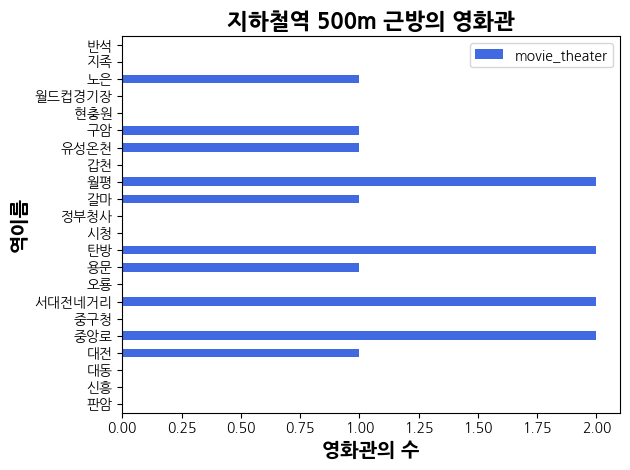

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'  # 또는 다른 한글 폰트 (예: 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 그래프 그리기(가로 막대그래프)
ax = movie_theater.plot.barh(x='역이름', y='movie_theater', color="royalblue")


# 그래프 제목 및 축 레이블 설정
ax.set_title("지하철역 500m 근방의 영화관", fontsize=16, fontweight='bold')  # 제목 추가
ax.set_xlabel("영화관의 수", fontsize=14, fontweight='bold')  # x축 제목
ax.set_ylabel("역이름", fontsize=14, fontweight='bold')  # y축 제목

# 그래프 표시
plt.tight_layout()  # 레이아웃 자동 조정
plt.show()

In [6]:
# CSV 파일 불러오기
data = pd.read_csv('data_base.csv')

# 상위 다섯개 행 확인
data.head(5)

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,87,85,93,77,41,46,28,21,17,3
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,102,98,107,77,97,72,87,70,32,11
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,31,34,34,28,13,19,21,9,2,0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,25,37,32,31,34,29,38,22,19,2
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,107,97,80,71,44,57,40,27,19,0


In [7]:
# movie_theater_count 딕셔너리
movie_theater_count = {
1101:0, 1102:0, 1103:0, 1104:1, 1105:2, 1106:0, 1107:2, 1108:0, 1109:1, 1110:2, 1111:0, 1112:0, 1113:1, 1114:2, 1115:0, 1116:1, 1117:1, 1118:0, 1119:0, 1120:1, 1121:0, 1122:0,
}

# STATION_NO 값에 따라 'movie_theater' 열 추가
data['movie_theater'] = data['STATION_NO'].map(movie_theater_count)
data

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,movie_theater
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,0
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,0
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,0
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60231,2024-09-30,1120,하차,0,0,0,0,19,40,198,...,349,404,576,321,191,237,168,96,27,1
60232,2024-09-30,1121,승차,0,0,0,0,40,79,170,...,143,216,481,152,113,82,40,25,0,0
60233,2024-09-30,1121,하차,0,0,0,0,20,39,132,...,128,162,209,114,92,85,87,59,11,0
60234,2024-09-30,1122,승차,0,0,0,0,72,204,903,...,400,527,833,394,261,253,239,114,0,0


In [4]:
# 엑셀 파일로 저장
data.to_excel('movie_theater_count.xlsx', index=False)

### 지하철 합계 추가 코드

In [403]:
import pandas as pd
from datetime import datetime

In [470]:
### 파일선택
df_1 = r"C:\Users\LG\Desktop\class\Machine learning\2021_raw.csv"
df_2 = r"C:\Users\LG\Desktop\class\Machine learning\2022_raw.csv"
df_3 = r"C:\Users\LG\Desktop\class\Machine learning\2023_raw.csv"
df_4 = r"C:\Users\LG\Desktop\class\Machine learning\대전교통공사_시간대별 승하차인원_20241031.csv"

In [471]:
df_1 = pd.read_csv(df_1,encoding="cp949")
df_2 = pd.read_csv(df_2,encoding="cp949")
df_3 = pd.read_csv(df_3,encoding="cp949")
df_4 = pd.read_csv(df_4,encoding="cp949")

In [472]:
def get_weekday(date):
    return date.weekday()

In [473]:
# df_4의 경우, 열 이름 변경 후 그룹화 적용
df_4.columns = ['BUSINESS_DAY', 'STATION_NO', '역명', '승ㆍ하차 구분', 'CNT01', 'CNT02', 'CNT03',
                'CNT04', 'CNT05', 'CNT06', 'CNT07', 'CNT08', 'CNT09', 'CNT10', 'CNT11',
                'CNT12', 'CNT13', 'CNT14', 'CNT15', 'CNT16', 'CNT17', 'CNT18', 'CNT19',
                'CNT20', 'CNT21', 'CNT22', 'CNT23', 'CNT00']

In [474]:
# 날짜 보정
df_1["BUSINESS_DAY"] = pd.to_datetime(df_1["BUSINESS_DAY"], format="%Y%m%d")
df_2["BUSINESS_DAY"] = pd.to_datetime(df_2["BUSINESS_DAY"], format="%Y%m%d")
df_3["BUSINESS_DAY"] = pd.to_datetime(df_3["BUSINESS_DAY"], format="%Y%m%d")
df_4["BUSINESS_DAY"] = pd.to_datetime(df_4["BUSINESS_DAY"], format="%Y-%m-%d")

# 주말데이터만 추출
df_1["week"] = df_1["BUSINESS_DAY"].apply(get_weekday)
df_1 = df_1[df_1["week"].isin([5, 6])]
df_2["week"] = df_2["BUSINESS_DAY"].apply(get_weekday)
df_2 = df_2[df_2["week"].isin([5, 6])]
df_3["week"] = df_3["BUSINESS_DAY"].apply(get_weekday)
df_3 = df_3[df_3["week"].isin([5, 6])]
df_4["week"] = df_4["BUSINESS_DAY"].apply(get_weekday)
df_4 = df_4[df_4["week"].isin([5, 6])]

# 공휴일 삭제
#df_1 = df_1[~df_1['BUSINESS_DAY'].isin([pd.to_datetime('2021-01-01'), pd.to_datetime('2021-12-25'), pd.to_datetime('2021-12-26')])]
df_2 = df_2[~df_2['BUSINESS_DAY'].isin([pd.to_datetime('2022-01-01'), pd.to_datetime('2022-01-29'), pd.to_datetime('2022-01-30'), pd.to_datetime('2022-01-31'), pd.to_datetime('2022-12-24'), pd.to_datetime('2022-12-25')])]
df_3 = df_3[~df_3['BUSINESS_DAY'].isin([pd.to_datetime('2023-01-01'), pd.to_datetime('2023-01-21'), pd.to_datetime('2023-01-22'), pd.to_datetime('2023-01-23'), pd.to_datetime('2023-01-24'), pd.to_datetime('2023-12-23'), pd.to_datetime('2023-12-24'), pd.to_datetime('2023-12-25'), pd.to_datetime('2023-12-30'), pd.to_datetime('2023-12-31')])]
df_4 = df_4[~df_4['BUSINESS_DAY'].isin([pd.to_datetime('2024-01-01'),pd.to_datetime('2024-02-09'),pd.to_datetime('2024-02-10'),pd.to_datetime('2024-02-11'),
                                        pd.to_datetime('2024-02-12'),pd.to_datetime('2024-03-01'),pd.to_datetime('2024-03-02'),pd.to_datetime('2024-03-03'),
                                        pd.to_datetime('2024-04-10'),pd.to_datetime('2024-05-04'),pd.to_datetime('2024-05-05'),pd.to_datetime('2024-05-06'),
                                        pd.to_datetime('2024-05-15'),pd.to_datetime('2024-06-06'),pd.to_datetime('2024-08-15'),pd.to_datetime('2024-09-14'),
                                        pd.to_datetime('2024-09-15'),pd.to_datetime('2024-09-16'),pd.to_datetime('2024-09-17'),pd.to_datetime('2024-09-18'),pd.to_datetime('2024-01-01'),
                                        pd.to_datetime('2024-10-01'),pd.to_datetime('2024-10-03'),pd.to_datetime('2024-10-09')])]

# 승차권 종류 열 삭제
df_1 = df_1.drop("승차권 종류", axis=1)
df_2 = df_2.drop("승차권 종류", axis=1)
df_3 = df_3.drop("승차권 종류", axis=1)
#df_4 = df_4.drop("승차권 종류", axis=1)

df_1 = df_1.drop("TOTAL_CNT", axis=1)
df_2 = df_2.drop("TOTAL_CNT", axis=1)
df_3 = df_3.drop("TOTAL_CNT", axis=1)
df_4 = df_4.drop("역명", axis=1)

# 승차 데이터 추출
df_1 = df_1[df_1['승ㆍ하차 구분'] == '승차']
df_2 = df_2[df_2['승ㆍ하차 구분'] == '승차']
df_3 = df_3[df_3['승ㆍ하차 구분'] == '승차']
df_4 = df_4[df_4['승ㆍ하차 구분'] == '승차']

df_1[['CNT01', 'CNT02', 'CNT03', 'CNT04']] = 0
df_2[['CNT01', 'CNT02', 'CNT03', 'CNT04']] = 0
df_3[['CNT01', 'CNT02', 'CNT03', 'CNT04']] = 0
#df_4[['CNT01', 'CNT02', 'CNT03', 'CNT04']] = 0

In [475]:
#df_1.to_csv("df_1.csv", index=False)
#df_2.to_csv("df_2.csv", index=False)
#df_3.to_csv("df_3.csv", index=False)
#df_4.to_csv("df_4.csv", index=False)

----------------------------------------------------------------

In [476]:
df_4.columns

Index(['BUSINESS_DAY', 'STATION_NO', '승ㆍ하차 구분', 'CNT01', 'CNT02', 'CNT03',
       'CNT04', 'CNT05', 'CNT06', 'CNT07', 'CNT08', 'CNT09', 'CNT10', 'CNT11',
       'CNT12', 'CNT13', 'CNT14', 'CNT15', 'CNT16', 'CNT17', 'CNT18', 'CNT19',
       'CNT20', 'CNT21', 'CNT22', 'CNT23', 'CNT00', 'week'],
      dtype='object')

In [477]:
# 그룹화를 수행하는 함수 정의
def group_by_station_and_day(df):
    return df.groupby(['BUSINESS_DAY', 'STATION_NO'])[
        ['CNT01', 'CNT02', 'CNT03', 'CNT04', 'CNT05', 'CNT06', 'CNT07', 
         'CNT08', 'CNT09', 'CNT10', 'CNT11', 'CNT12', 'CNT13', 'CNT14', 
         'CNT15', 'CNT16', 'CNT17', 'CNT18', 'CNT19', 'CNT20', 'CNT21', 
         'CNT22', 'CNT23', 'CNT00']].sum().reset_index()

# 데이터프레임 별로 그룹화 적용
df_1_total = group_by_station_and_day(df_1)
df_2_total = group_by_station_and_day(df_2)
df_3_total = group_by_station_and_day(df_3)
df_4_total = group_by_station_and_day(df_4)


In [478]:
df_4_total

,BUSINESS_DAY,STATION_NO,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,CNT08,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,2024-01-06,1101,0,0,0,0,0,66,97,163,...,214,196,235,215,164,95,94,49,30,19
1,2024-01-06,1102,0,0,0,0,0,36,40,63,...,78,98,94,81,47,59,30,25,9,5
2,2024-01-06,1103,1,0,0,0,0,50,76,138,...,178,185,219,232,157,120,85,63,38,25
3,2024-01-06,1104,0,0,0,0,0,22,71,149,...,896,1046,1159,950,739,523,548,486,416,221
4,2024-01-06,1105,6,0,0,0,0,24,29,55,...,446,589,706,687,650,534,585,460,289,172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1667,2024-10-27,1118,0,0,0,0,0,7,13,37,...,175,186,172,101,82,65,54,50,8,3
1668,2024-10-27,1119,0,0,0,0,0,18,36,43,...,126,141,1976,337,111,64,71,75,19,4
1669,2024-10-27,1120,1,0,0,0,0,22,36,66,...,152,154,183,189,189,136,103,92,65,28
1670,2024-10-27,1121,0,0,0,0,0,16,33,43,...,69,68,60,71,47,49,30,31,17,6


In [479]:
df_1_total.to_csv("df_1_total.csv", index=False)
df_2_total.to_csv("df_2_total.csv", index=False)
df_3_total.to_csv("df_3_total.csv", index=False)
df_4_total.to_csv("df_4_total.csv", index=False)

In [480]:
df_4_total.to_csv('24_total_testdata.csv')

In [ ]:
#data = pd.concat([df_1_total, df_2_total, df_3_total, df_4_total], ignore_index=True)
#data.to_csv("all_total.csv", index=False)

-------------------------------------

#### 여기부터 시작

In [517]:
all_total_df = pd.read_csv("data_base.csv", encoding='cp949')
school_festival = pd.read_excel('대학교 축제.xlsx')
deajeon_festival = pd.read_csv('대전 축제.csv', encoding='cp949')
transfer = pd.read_csv("버스지하철환승.csv", encoding='cp949')

In [520]:
# 1. BUSINESS_DAY를 문자열로 변환 (필요한 경우)
if not all_total_df['BUSINESS_DAY'].dtype == 'object':
    all_total_df['BUSINESS_DAY'] = all_total_df['BUSINESS_DAY'].astype(str)

# 2. 날짜 형식으로 변환
all_total_df['BUSINESS_DAY'] = pd.to_datetime(all_total_df['BUSINESS_DAY'], format='%Y-%m-%d', errors='coerce')

all_total_df['Month'] = all_total_df['BUSINESS_DAY'].dt.month
all_total_df['Day'] = all_total_df['BUSINESS_DAY'].dt.day

# 결과 확인
print(all_total_df[['BUSINESS_DAY', 'Month', 'Day']].head())

  BUSINESS_DAY  Month  Day
0   2021-01-01      1    1
1   2021-01-01      1    1
2   2021-01-01      1    1
3   2021-01-01      1    1
4   2021-01-01      1    1


In [ ]:
school_festival['uni_start'] = pd.to_datetime(school_festival['uni_start'], format='%Y%m%d')
school_festival['uni_end'] = pd.to_datetime(school_festival['uni_end'], format='%Y%m%d')
school_festival['uni_start_Month_Day'] = school_festival['uni_start'].apply(lambda x: (x.month, x.day))
school_festival['uni_end_Month_Day'] = school_festival['uni_end'].apply(lambda x: (x.month, x.day))

all_total_df['Month_Day'] = all_total_df.apply(lambda row: (row['Month'], row['Day']), axis=1)

# 초기 값 설정
all_total_df['school_festival'] = 0

# 각 행사의 월과 일 범위와 비교하여 해당하는 경우 1로 설정
for _, event in school_festival.iterrows():
    start = event['uni_start_Month_Day']
    end = event['uni_end_Month_Day']
    all_total_df.loc[all_total_df['Month_Day'].apply(lambda x: start <= x <= end), 'school_festival'] = 1

def label_weekday(day):
    if day in ['Saturday', 'Friday', 'Sunday']:
        return 1
    else:
        return 0

all_total_df['BUSINESS_DAY'] = all_total_df['weekday'].apply(label_weekday)

all_total_df['season'] = 0
all_total_df.loc[all_total_df['Month'].isin([2,3,4]), 'season'] = 0
all_total_df.loc[all_total_df['Month'].isin([5,6,7]), 'season'] = 1
all_total_df.loc[all_total_df['Month'].isin([8,9,10]), 'season'] = 2
all_total_df.loc[all_total_df['Month'].isin([11,12,1]), 'season'] = 3
all_total_df

KeyError: 'weekday'

In [127]:
### 버스 -> 지하철 환승인원 데이터
bus_to_subway_data = pd.read_csv(r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\버스지하철환승22.csv", encoding='cp949')


In [130]:
import chardet

# 파일의 인코딩 확인
with open(r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\data_base.csv", "rb") as f:
    result = chardet.detect(f.read())
    print(result)


{'encoding': 'utf-8', 'confidence': 0.99, 'language': ''}


In [133]:
merged_data = pd.read_csv(r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\data_base.csv", encoding='utf-8')


In [402]:
# 1. 데이터 결합
# '총합계'가 있는 버스 데이터를 '년'과 'STATION_NO' 기준으로 결합
per = pd.merge(
    all_total_df,
    bus_to_subway_data[['년', '역번호', '총합계']],  # 필요한 열만 사용
    left_on=['년', 'STATION_NO'],        # 기준 열
    right_on=['년', '역번호'],           # 기준 열
    how='left'
)

# 2. 데이터 타입 변환
# '총합계'를 숫자형으로 변환, 변환 실패 시 NaN은 0으로 대체
per['총합계'] = pd.to_numeric(per['총합계'], errors='coerce').fillna(0)

# 3. 지하철 이용량 합계 계산
# 시간대별 'CNTxx' 열 합계로 '지하철_합계' 열 생성
time_columns = [f'CNT{i:02}' for i in range(24)]  # CNT00, CNT01, ..., CNT23
per['지하철_합계'] = per[time_columns].sum(axis=1)

# 4. 환승 비율 계산
# 특정 연도(2022, 2023)만 처리하며, '지하철_합계'가 0보다 큰 경우에만 나눗셈
per['환승비율'] = 0  # 초기값 설정
per.loc[
    (per['년'].isin([2022, 2023])) & (per['지하철_합계'] > 0),  # 조건 설정
    '환승비율'
] = per['총합계'] / per['지하철_합계']

# 5. 결과 확인
data_2022 = per[per['년'] == 2022]
data_2022

,BUSINESS_DAY,STATION_NO,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,CNT08,...,년,월,일,Month_Day,school_festival,season,역번호,총합계,지하철_합계,환승비율
2244,2022-01-02,1101,0,0,0,0,47,47,57,100,...,2022,1,2,"(1, 2)",0,3,1101,0.0,1910,0
2245,2022-01-02,1102,0,0,0,0,13,12,20,31,...,2022,1,2,"(1, 2)",0,3,1102,0.0,678,0
2246,2022-01-02,1103,0,0,0,0,30,27,47,83,...,2022,1,2,"(1, 2)",0,3,1103,0.0,1608,0
2247,2022-01-02,1104,0,0,0,0,13,21,51,99,...,2022,1,2,"(1, 2)",0,3,1104,0.0,7852,0
2248,2022-01-02,1105,0,0,0,0,10,19,18,27,...,2022,1,2,"(1, 2)",0,3,1105,0.0,3657,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4439,2022-12-31,1118,0,0,0,0,10,11,45,84,...,2022,12,31,"(12, 31)",0,3,1118,0.0,1402,0
4440,2022-12-31,1119,0,0,0,0,11,40,54,79,...,2022,12,31,"(12, 31)",0,3,1119,0.0,1757,0
4441,2022-12-31,1120,0,0,0,0,32,39,60,141,...,2022,12,31,"(12, 31)",0,3,1120,0.0,3101,0
4442,2022-12-31,1121,0,0,0,0,12,22,50,82,...,2022,12,31,"(12, 31)",0,3,1121,0.0,1390,0


In [170]:
print(merged_data['총합계'].head())  # 총합계 확인


0    11209.0
1    15444.0
2     7513.0
3    11418.0
4     9669.0
Name: 총합계, dtype: float64


### 열차시각표

In [113]:
from datetime import datetime

time_data = pd.read_csv("열차시각표(휴일 상선).csv", encoding='cp949')
time_data_2 = pd.read_csv("열차시각표(휴일 하선).csv", encoding='cp949')

In [114]:
def convert_time(value):
    if isinstance(value, str) and ":" in value:  # 값이 문자열이고 ":"를 포함할 경우
        try:
            return pd.to_datetime(value.strip(), format='%H:%M').time()
        except ValueError:
            return None  # 형식이 맞지 않는 값은 None으로 처리
    return None  # 숫자, NaN 등 다른 값 처리

In [115]:
# 데이터의 문자열 공백 제거
time_data = time_data.applymap(lambda x: x.strip() if isinstance(x, str) else x)
time_data_2 = time_data_2.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# 변환 후 확인
for col in time_data_2.columns[2:]:
    print(f"Column {col}: {time_data_2[col].dropna().unique()}")

# 변환 후 확인
for col in time_data.columns[2:]:
    print(f"Column {col}: {time_data[col].dropna().unique()}")

Column 1003: ['5:30' '5:31' '5:34' '5:36' '5:38' '5:40' '5:41' '5:43' '5:45' '5:47'
 '5:49' '5:51' '5:53' '5:54' '5:56' '5:58']
Column 1005: ['5:30' '5:32' '5:34' '5:36' '5:38' '5:39' '5:41' '5:43' '5:45' '5:48'
 '5:49' '5:51' '5:53' '5:55' '5:57' '5:59' '6:01' '6:02' '6:04' '6:06'
 '6:08' '6:10']
Column 1007: ['5:45' '5:47' '5:49' '5:51' '5:53' '5:54' '5:56' '5:58' '6:00' '6:03'
 '6:04' '6:06' '6:08' '6:10' '6:12' '6:14' '6:16' '6:17' '6:19' '6:21'
 '6:23' '6:25']
Column 1009: ['6:00' '6:02' '6:04' '6:06' '6:08' '6:09' '6:11' '6:13' '6:15' '6:18'
 '6:19' '6:21' '6:23' '6:25' '6:27' '6:29' '6:31' '6:32' '6:34' '6:36'
 '6:38' '6:40']
Column 1011: ['6:12' '6:14' '6:16' '6:18' '6:20' '6:21' '6:23' '6:25' '6:27' '6:30'
 '6:31' '6:33' '6:35' '6:37' '6:39' '6:41' '6:43' '6:44' '6:46' '6:48'
 '6:50' '6:52']
Column 1013: ['6:24' '6:26' '6:28' '6:30' '6:32' '6:33' '6:35' '6:37' '6:39' '6:42'
 '6:43' '6:45' '6:47' '6:49' '6:51' '6:53' '6:55' '6:56' '6:58' '7:00'
 '7:02' '7:04']
Column 1015: ['6:

C:\Users\LG\AppData\Local\Temp\ipykernel_12448\4289621504.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  time_data = time_data.applymap(lambda x: x.strip() if isinstance(x, str) else x)
C:\Users\LG\AppData\Local\Temp\ipykernel_12448\4289621504.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  time_data_2 = time_data_2.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [116]:
# 시간 데이터를 숫자형으로 변환하는 함수 정의
def time_to_numeric(time_str):
    if pd.isna(time_str):  # 결측치 확인
        return None  # 결측치는 None 반환 (NaN으로 처리됨)
    try:
        # 시간 문자열을 시와 분으로 분리
        h, m = map(int, time_str.split(':'))
        return h + m / 60
    except ValueError:
        # 시간 형식이 아닌 데이터는 None 반환
        return None
    
# 데이터프레임의 시간 열을 숫자형으로 변환 (첫 번째 열 제외)
for col in time_data.columns[1:]:
    time_data[col] = time_data[col].apply(time_to_numeric)
    
# 데이터프레임의 시간 열을 숫자형으로 변환 (첫 번째 열 제외)
for col in time_data_2.columns[1:]:
    time_data_2[col] = time_data_2[col].apply(time_to_numeric)

In [117]:
time_data.fillna(0, inplace=True)  
time_data_2.fillna(0, inplace=True)  
time_data = time_data.applymap(lambda x: round(x, 2) if isinstance(x, (int, float)) else x)
time_data_2 = time_data_2.applymap(lambda x: round(x, 2) if isinstance(x, (int, float)) else x)

C:\Users\LG\AppData\Local\Temp\ipykernel_12448\34738299.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  time_data = time_data.applymap(lambda x: round(x, 2) if isinstance(x, (int, float)) else x)
C:\Users\LG\AppData\Local\Temp\ipykernel_12448\34738299.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  time_data_2 = time_data_2.applymap(lambda x: round(x, 2) if isinstance(x, (int, float)) else x)


In [63]:
import pandas as pd

# 파일 경로 설정
file_path = r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\버스지하철환승22.csv"

# CSV 파일을 읽기
try:
    df = pd.read_csv(file_path, encoding='cp949')  # 인코딩이 cp949일 경우
    print(df.head())  # 데이터 확인 (첫 5행 출력)
except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {file_path}")
except Exception as e:
    print(f"오류 발생: {e}")



      년   역번호   역명      총합계  00~01시  01~02시  02~03시  03~04시  04~05시  05~06시  \
0  2022  1101   판암  234,271       0       0       0       0       0     323   
1  2022  1102   신흥   61,226       1       0       0       0       0     201   
2  2022  1103   대동  385,678       0       0       0       0       0     879   
3  2022  1104   대전  227,614      47       0       0       0       0     347   
4  2022  1105  중앙로  159,943       1       0       0       0       0     676   

   ...  14~15시  15~16시  16~17시  17~18시  18~19시  19~20시  20~21시  21~22시  \
0  ...   12342   12458   15252   17518   16584    6597    4278    2667   
1  ...    2334    2498    3950    3876    4262    1552    1111    1237   
2  ...   20654   26463   34317   36469   36388   13025    8355    7245   
3  ...   12369   13099   15559   18030   20298   10809    6431    6001   
4  ...    8535    9035   11579   13477   13800    6867    4498    3693   

   22~23시  23~00시  
0    1765     696  
1     395      86  
2    5186    2052  


In [64]:
!pip install chardet


In [82]:

import pandas as pd

with open(r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\버스지하철환승22.csv", encoding='cp949', errors='replace') as f:
    bus_to_subway_data = pd.read_csv(f)



In [83]:
bus_to_subway_data.head()

,년,역번호,역명,총합계,00~01시,01~02시,02~03시,03~04시,04~05시,05~06시,...,14~15시,15~16시,16~17시,17~18시,18~19시,19~20시,20~21시,21~22시,22~23시,23~00시
0,2022,1101,판암,"234,271",0,0,0,0,0,323,...,12342,12458,15252,17518,16584,6597,4278,2667,1765,696
1,2022,1102,신흥,"61,226",1,0,0,0,0,201,...,2334,2498,3950,3876,4262,1552,1111,1237,395,86
2,2022,1103,대동,"385,678",0,0,0,0,0,879,...,20654,26463,34317,36469,36388,13025,8355,7245,5186,2052
3,2022,1104,대전,"227,614",47,0,0,0,0,347,...,12369,13099,15559,18030,20298,10809,6431,6001,4483,2933
4,2022,1105,중앙로,"159,943",1,0,0,0,0,676,...,8535,9035,11579,13477,13800,6867,4498,3693,2901,1489


In [84]:
# utf-8 인코딩으로 읽어보기
with open(r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\data_base.csv", encoding='utf-8', errors='replace') as f:
    data = pd.read_csv(f)


In [85]:
data.head()

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,87,85,93,77,41,46,28,21,17,3
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,102,98,107,77,97,72,87,70,32,11
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,31,34,34,28,13,19,21,9,2,0
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,25,37,32,31,34,29,38,22,19,2
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,107,97,80,71,44,57,40,27,19,0


In [86]:
import chardet

# 파일 경로
file_path = r"C:\Users\LG\OneDrive\Desktop\동인구 전처리\2023.11.3주차\버스지하철환승22.csv"

# 인코딩 감지
with open(file_path, 'rb') as f:
    result = chardet.detect(f.read())

print(result)  # 인코딩 정보 확인


{'encoding': 'EUC-KR', 'confidence': 0.99, 'language': 'Korean'}


In [98]:
# '년'을 기준으로 'YEAR' 열 생성
bus_to_subway_data['YEAR'] = bus_to_subway_data['년']
# BUSINESS_DAY에서 연도만 추출하여 YEAR 열 생성
data['YEAR'] = pd.to_datetime(data['BUSINESS_DAY']).dt.year



In [125]:
bus_to_subway_data

,년,역번호,역명,총합계,00~01시,01~02시,02~03시,03~04시,04~05시,05~06시,...,15~16시,16~17시,17~18시,18~19시,19~20시,20~21시,21~22시,22~23시,23~00시,YEAR
0,2022,1101,판암,"234,271",0,0,0,0,0,323,...,12458,15252,17518,16584,6597,4278,2667,1765,696,2022
1,2022,1102,신흥,"61,226",1,0,0,0,0,201,...,2498,3950,3876,4262,1552,1111,1237,395,86,2022
2,2022,1103,대동,"385,678",0,0,0,0,0,879,...,26463,34317,36469,36388,13025,8355,7245,5186,2052,2022
3,2022,1104,대전,"227,614",47,0,0,0,0,347,...,13099,15559,18030,20298,10809,6431,6001,4483,2933,2022
4,2022,1105,중앙로,"159,943",1,0,0,0,0,676,...,9035,11579,13477,13800,6867,4498,3693,2901,1489,2022
5,2022,1106,중구청,"23,049",0,0,0,0,0,238,...,1344,1647,1766,2021,951,678,723,472,165,2022
6,2022,1107,서대전네거리,"278,350",0,0,0,0,0,648,...,12334,15154,16123,17664,7801,4926,4638,3272,979,2022
7,2022,1108,오룡,"142,207",0,0,0,0,0,100,...,5955,7490,9429,10377,4588,2698,2053,1516,605,2022
8,2022,1109,용문,"207,921",0,0,0,0,0,1165,...,10898,13161,14707,15243,7766,5469,4542,2909,988,2022
9,2022,1110,탄방,"36,410",0,0,0,0,0,12,...,2450,2771,3317,3316,1753,1257,1116,1135,234,2022


In [99]:
data

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,YEAR
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,2021
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,2021
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,2021
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,2021
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60231,2024-09-30,1120,하차,0,0,0,0,19,40,198,...,349,404,576,321,191,237,168,96,27,2024
60232,2024-09-30,1121,승차,0,0,0,0,40,79,170,...,143,216,481,152,113,82,40,25,0,2024
60233,2024-09-30,1121,하차,0,0,0,0,20,39,132,...,128,162,209,114,92,85,87,59,11,2024
60234,2024-09-30,1122,승차,0,0,0,0,72,204,903,...,400,527,833,394,261,253,239,114,0,2024


In [118]:
print(df.columns)


Index(['지하철_합계', '환승비율'], dtype='object')


In [119]:
df.columns = df.columns.str.strip()  # 공백 제거

In [143]:
import pandas as pd

# 시간대 열 정의 (CNT00 ~ CNT23)
time_columns = [f'CNT{i:02}' for i in range(24)]  # CNT00, CNT01, ..., CNT23

# merged_data 데이터프레임에 '지하철_합계' 열 추가
data['지하철_합계'] = data[time_columns].sum(axis=1)

# 결과 확인
print(data[['STATION_NO', '지하철_합계']].head())

  STATION_NO  지하철_합계
0       1101    1211
1       1101    1225
2       1102     464
3       1102     451
4       1103    1142


In [148]:
data

,BUSINESS_DAY,STATION_NO,get_on_off,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,...,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,지하철_합계
0,2021-01-01,1101,승차,0,0,0,0,37,35,53,...,85,93,77,41,46,28,21,17,3,1211
1,2021-01-01,1101,하차,0,0,0,0,8,17,34,...,98,107,77,97,72,87,70,32,11,1225
2,2021-01-01,1102,승차,0,0,0,0,11,16,14,...,34,34,28,13,19,21,9,2,0,464
3,2021-01-01,1102,하차,0,0,0,0,1,8,13,...,37,32,31,34,29,38,22,19,2,451
4,2021-01-01,1103,승차,0,0,0,0,24,25,37,...,97,80,71,44,57,40,27,19,0,1142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60231,2024-09-30,1120,하차,0,0,0,0,19,40,198,...,349,404,576,321,191,237,168,96,27,4719
60232,2024-09-30,1121,승차,0,0,0,0,40,79,170,...,143,216,481,152,113,82,40,25,0,2611
60233,2024-09-30,1121,하차,0,0,0,0,20,39,132,...,128,162,209,114,92,85,87,59,11,2595
60234,2024-09-30,1122,승차,0,0,0,0,72,204,903,...,400,527,833,394,261,253,239,114,0,8108


### 버스유동인구 추가 코드

In [ ]:
# 다운받은 파일을 한 파일(주별)로 결합
import pandas as pd

# 각 CSV 파일 경로 리스트
csv_files = [
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (1).csv",
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (2).csv",
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (3).csv",
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (4).csv",
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (5).csv",
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (6).csv",
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (7).csv",
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (8).csv",
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (9).csv",
r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주\1_노선·정류장 지표(정류장별 이용량)_20241127 (10).csv"
    ]
# 개별 CSV 파일들을 읽어서 데이터프레임으로 변환 후 리스트에 저장
dataframes = [pd.read_csv(file, encoding='latin1') for file in csv_files]

# concat을 사용하여 데이터프레임 병합
merged_data = pd.concat(dataframes, ignore_index=True)

# 컬럼중 '노선', '이용자유형', '기종점' 제거
merged_data = df.drop(['노선', '이용자유형', '기종점', 'unnamed:54'], axis=1)
merged_data

# 컬럼명 바꾸는 코드
new_columns = [
    'BUSSTATION_NO', 'BUSINESS_DAY', 
    '01(승차)', '01(하차)', '02(승차)', '02(하차)', '03(승차)', '03(하차)', 
    '04(승차)', '04(하차)', '05(승차)', '05(하차)', '06(승차)', '06(하차)', 
    '07(승차)', '07(하차)', '08(승차)', '08(하차)', '09(승차)', '09(하차)', 
    '10(승차)', '10(하차)', '11(승차)', '11(하차)', '12(승차)', '12(하차)', 
    '13(승차)', '13(하차)', '14(승차)', '14(하차)', '15(승차)', '15(하차)', 
    '16(승차)', '16(하차)', '17(승차)', '17(하차)', '18(승차)', '18(하차)', 
    '19(승차)', '19(하차)', '20(승차)', '20(하차)', '21(승차)', '21(하차)', 
    '22(승차)', '22(하차)', '23(승차)', '23(하차)', '00(승차)', '00(하차)'
]

# 데이터프레임의 컬럼명을 변경
df.columns = new_columns

# BUSINESS_DAY 열에서 괄호와 요일 제거
df['BUSINESS_DAY'] = df['BUSINESS_DAY'].str.replace(r"\s*\(.*\)", "", regex=True)
df['BUSINESS_DAY']

# 컬럼명에서 "(승차)", "(하차)" 제거
df.columns = df.columns.str.replace(r'\(승차\)', '', regex=True).str.replace(r'\(하차\)', '', regex=True).str.strip()

# BUSSTATION_NO와 BUSINESS_DAY를 기준으로 그룹화 후 시간대별 컬럼 합산
grouped_df = df.groupby(['BUSSTATION_NO', 'BUSINESS_DAY']).sum(numeric_only=True).reset_index()

# 결과 저장
output_path = r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주
a.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"결과 파일이 저장되었습니다: {output_path}")

CSV 파일이 병합되어 '2023.01.4주'로 저장되었습니다.


In [ ]:
a = pd.read_csv(r"C:\Users\user\바탕 화면\55\2023busstop\2023.11.4주" ,encoding="utf8")

# 열 이름 중 중복된 CNTx와 CNTx.1를 합치기
for col in a.columns:
    if col.endswith(".1"):
        original_col = col[:-2]  # ".1"을 제거하여 원래 열 이름 추출
        if original_col in a.columns:
            a[original_col] = a[original_col] + a[col]  # 두 열의 값을 합침
            a.drop(columns=[col], inplace=True)  # ".1"이 붙은 열 제거

# 결과 저장
output_path = r"C:\Users\user\바탕 화면\99\2023.11.4주_전처리b.csv"
a.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"결과 파일이 저장되었습니다: {output_path}")

In [ ]:
# csv파일로 저장되지 않을경우 csv파일로 변환하는 코드
import pandas as pd

# 파일 경로 지정
file_path = r"C:\Users\user\바탕 화면\찐최종\2024"

# 파일 읽기
try:
    # 파일 읽기
    df = pd.read_csv(file_path, encoding='utf-8')

    # 새 파일 저장 경로 설정
    save_path = r"C:\Users\user\바탕 화면\찐최종\2024.csv"

    # CSV로 저장 (Excel 호환)
    df.to_csv(save_path, index=False, encoding='utf-8-sig')  # utf-8-sig로 Excel에서 인식 가능하게 저장

    print(f"파일이 성공적으로 저장되었습니다: {save_path}")
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
except Exception as e:
    print(f"파일을 처리하는 중 오류가 발생했습니다: {e}")


파일이 성공적으로 저장되었습니다: C:\Users\user\바탕 화면\찐최종\2024.csv
